<a href="https://colab.research.google.com/github/mujtaba-mohiyuddin/ucb-traffic-sign-recognition/blob/master/UCB_Week_19_Project_Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Attrition Prediction

**Problem:** Predict whether an employee will leave (`Attrition`: Yes/No) using HR data — demographics, job details, compensation proxies, satisfaction scores, and tenure fields. This is a **binary classification** problem.

**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle), ~1,470 employees, ~35 raw columns.

**Key challenges to keep in mind throughout:**
- **Class imbalance** — most employees stay, so "attrition" is the minority class. Accuracy alone can be misleading; we lean on precision, recall, F1, and confusion matrices.
- **Mixed feature types** — numeric columns (age, income, tenure) and categorical columns (department, job role, overtime) need consistent encoding.
- **Overfitting risk** — flexible models (deep trees) can memorize the training set, so we compare train vs. test performance and use cross-validation.

## Cell 1 — Setup & Kaggle Download

In [2]:
!pip install -q kaggle scikit-learn seaborn

from google.colab import files
uploaded = files.upload()  # choose kaggle.json when prompted

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d pavansubhasht/ibm-hr-analytics-attrition-dataset
!unzip -q ibm-hr-analytics-attrition-dataset.zip -d attrition_data

Saving HR Attrition Data.csv to HR Attrition Data.csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
License(s): DbCL-1.0
100% 50.1k/50.1k [00:00<00:00, 39.3MB/s]



## Cell 2 — Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## Cell 3 — Load the Data

In [6]:
import glob
csv_path = glob.glob("attrition_data/*.csv")[0]
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## Cell 4 — EDA: Data Types, Missing Values, Target Balance
Learning objective 1: load and explore HR data (distributions, missing values, target balance).

In [7]:
print("Data types:\n")
print(df.dtypes)
print("\nMissing values per column:\n")
print(df.isnull().sum().sort_values(ascending=False).head(10))
print("\nDuplicate rows:", df.duplicated().sum())

Data types:

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWo

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


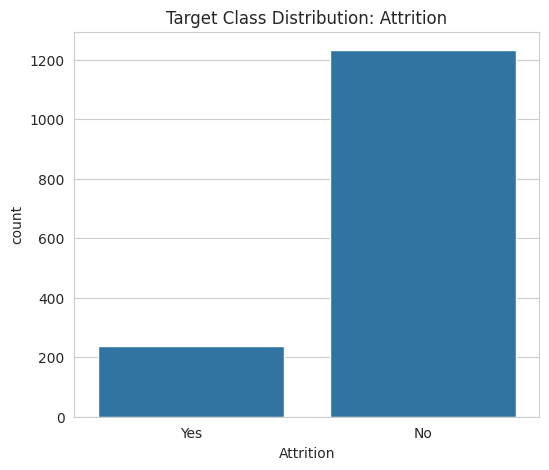

In [8]:
# Target balance - this is the class imbalance the problem statement warns about
print(df["Attrition"].value_counts())
print(df["Attrition"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,5))
sns.countplot(x="Attrition", data=df)
plt.title("Target Class Distribution: Attrition")
plt.show()

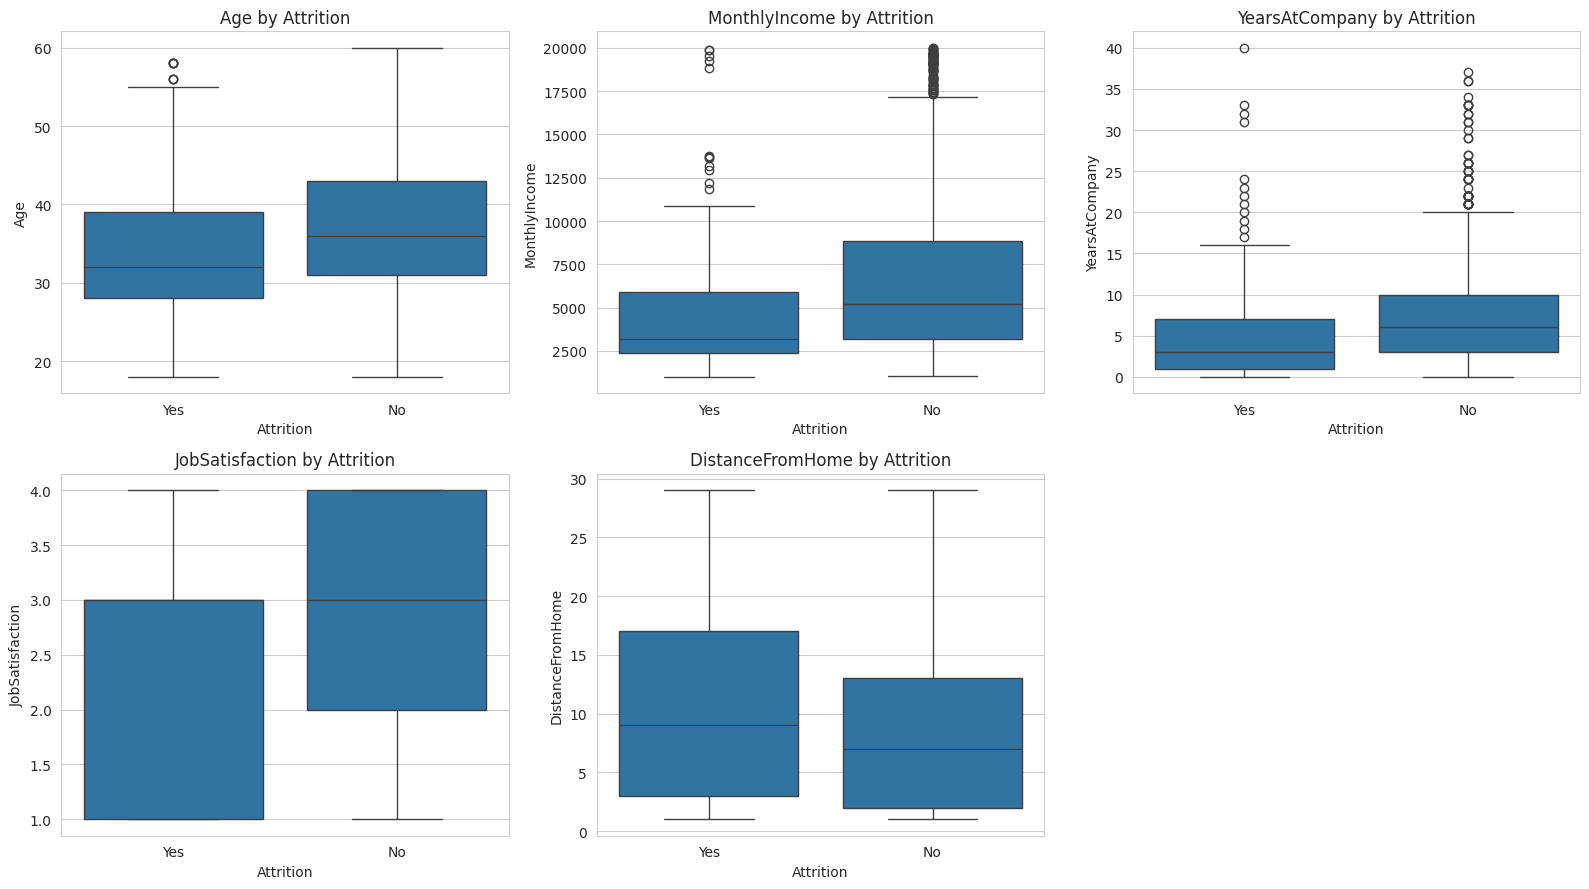

In [9]:
# Distribution of a few key numeric features, split by attrition status
numeric_cols_of_interest = ["Age", "MonthlyIncome", "YearsAtCompany", "JobSatisfaction", "DistanceFromHome"]

fig, axes = plt.subplots(2, 3, figsize=(16,9))
for ax, col in zip(axes.flatten(), numeric_cols_of_interest):
    sns.boxplot(x="Attrition", y=col, data=df, ax=ax)
    ax.set_title(f"{col} by Attrition")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

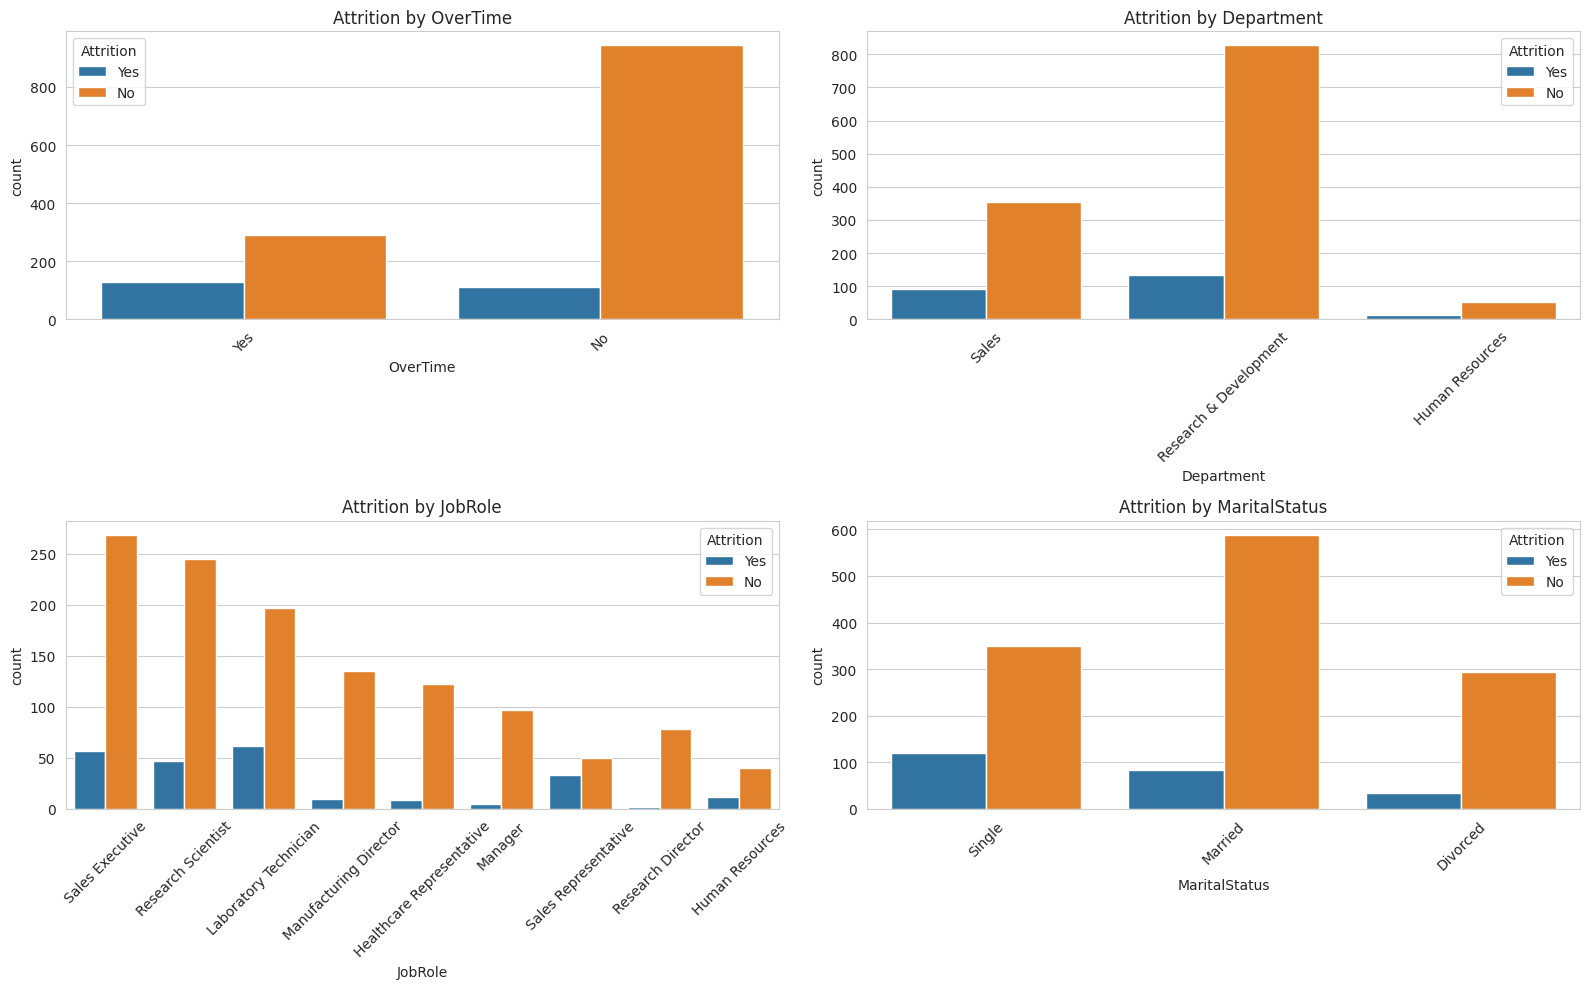

In [10]:
# A couple of key categorical features vs attrition
categorical_cols_of_interest = ["OverTime", "Department", "JobRole", "MaritalStatus"]

fig, axes = plt.subplots(2, 2, figsize=(16,10))
for ax, col in zip(axes.flatten(), categorical_cols_of_interest):
    sns.countplot(x=col, hue="Attrition", data=df, ax=ax)
    ax.set_title(f"Attrition by {col}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Cell 5 — Preprocess: Drop Non-Informative Columns, Encode Categoricals
Learning objective 2: drop or justify removal of non-informative columns, encode categoricals, prepare numeric features.

In [25]:
# Check for columns that carry no information (constant value across every row)
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"Constant column (no predictive value): {col} -> value: {df[col].unique()}")

Constant column (no predictive value): EmployeeCount -> value: [1]
Constant column (no predictive value): Over18 -> value: ['Y']
Constant column (no predictive value): StandardHours -> value: [80]


In [26]:
# Common non-informative columns in this dataset: EmployeeCount, StandardHours, Over18 are constant;
# EmployeeNumber is just an ID with no predictive meaning
cols_to_drop = [c for c in ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"] if c in df.columns]
print("Dropping:", cols_to_drop)

df_clean = df.drop(columns=cols_to_drop)

# Encode the target: Yes/No -> 1/0
df_clean["Attrition"] = df_clean["Attrition"].map({"Yes": 1, "No": 0})

# Identify categorical columns for encoding
categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()
print("\nCategorical columns to encode:", categorical_cols)

Dropping: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [27]:
# One-hot encode categorical columns (keeps them from being treated as ordinal/numeric by mistake)
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print("Shape before encoding:", df_clean.shape)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape before encoding: (1470, 31)
Shape after encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False


## Cell 6 — Train/Test Split
Learning objective 3: split data into training and test sets, and evaluate models fairly. We stratify by the target so both sets preserve the same class balance.

In [28]:
X = df_encoded.drop(columns=["Attrition"])
y = df_encoded["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train: (1176, 44) Test: (294, 44)
Train class balance:
 Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64
Test class balance:
 Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


## Cell 7 — Baseline and Advanced Classifiers
Learning objective 4: train baseline and advanced classifiers (e.g., decision trees, ensembles, gradient boosting).

In [29]:
models = {
    "Logistic Regression (baseline)": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_models = {}
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Attrition)": precision_score(y_test, y_pred),
        "Recall (Attrition)": recall_score(y_test, y_pred),
        "F1 (Attrition)": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values("F1 (Attrition)", ascending=False)
results_df

,Model,Accuracy,Precision (Attrition),Recall (Attrition),F1 (Attrition),ROC-AUC
0,Logistic Regression (baseline),0.751701,0.345238,0.617021,0.442748,0.798260
1,Decision Tree,0.761905,0.342466,0.531915,0.416667,0.634680
3,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.794125
2,Random Forest,0.840136,0.500000,0.085106,0.145455,0.768886


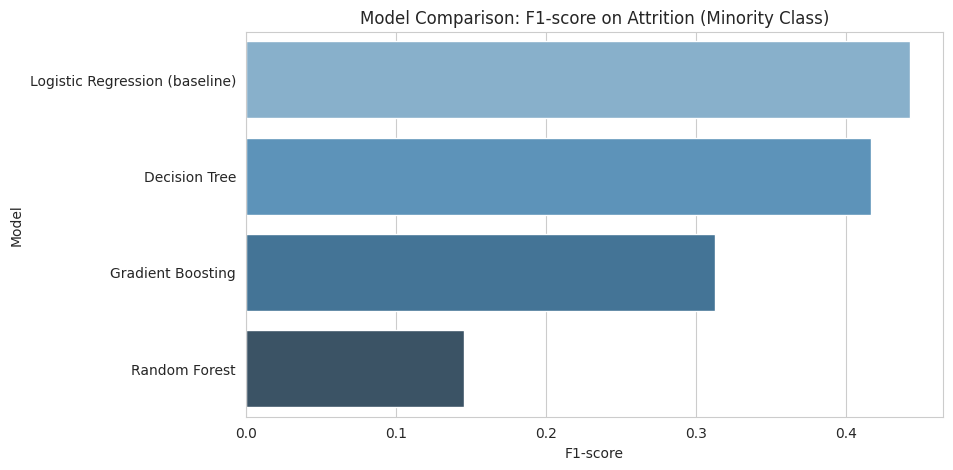

In [30]:
plt.figure(figsize=(9,5))
sns.barplot(x="F1 (Attrition)", y="Model", data=results_df, hue="Model", legend=False, palette="Blues_d")
plt.title("Model Comparison: F1-score on Attrition (Minority Class)")
plt.xlabel("F1-score")
plt.show()

## Cell 8 — Interpret Results: Classification Reports & Confusion Matrices
Learning objective 5: interpret results with classification reports and confusion matrices, especially for the minority class (attrition = Yes).

In [31]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Best model by F1 on the minority class: {best_model_name}\n")

y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=["No Attrition", "Attrition"]))

Best model by F1 on the minority class: Logistic Regression (baseline)

              precision    recall  f1-score   support

No Attrition       0.91      0.78      0.84       247
   Attrition       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



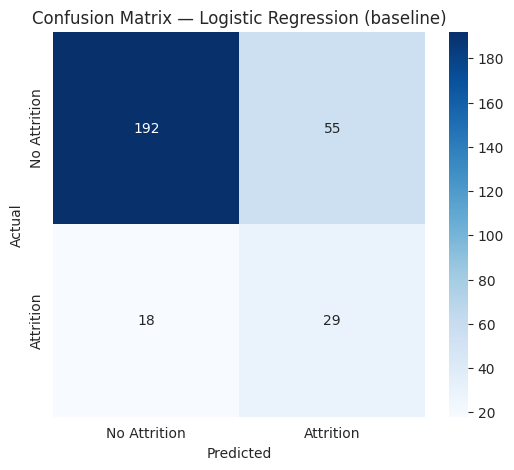

True Negatives (correctly predicted stay): 192
False Positives (predicted leave, actually stayed): 55
False Negatives (predicted stay, actually left): 18  <- the costly miss
True Positives (correctly predicted attrition): 29


In [32]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"], yticklabels=["No Attrition", "Attrition"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted stay): {tn}")
print(f"False Positives (predicted leave, actually stayed): {fp}")
print(f"False Negatives (predicted stay, actually left): {fn}  <- the costly miss")
print(f"True Positives (correctly predicted attrition): {tp}")

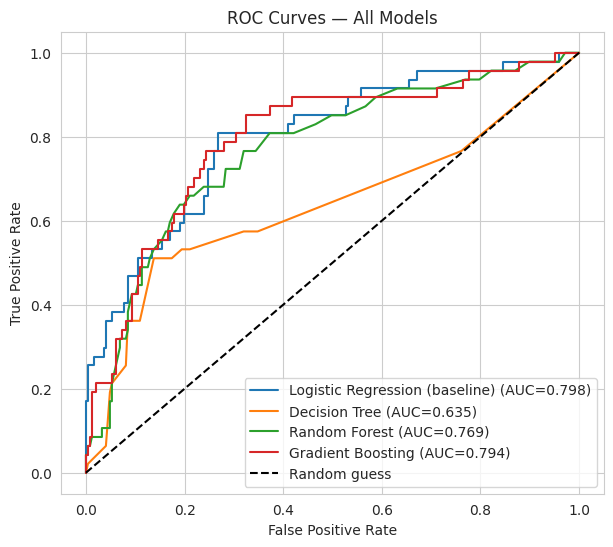

In [33]:
# ROC curves for all models, for a fuller picture than a single threshold's confusion matrix
plt.figure(figsize=(7,6))
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.show()

In [34]:
# Feature importance from the best tree-based model (skip gracefully if the best model has no feature_importances_)
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(9,7))
    sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False, palette="Blues_d")
    plt.title(f"Top 15 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_ directly (e.g. Logistic Regression uses coefficients instead).")

Logistic Regression (baseline) does not expose feature_importances_ directly (e.g. Logistic Regression uses coefficients instead).


## Cell 9 — Cross-Validation Check (Overfitting Sanity Check)
Compares training accuracy vs. cross-validated accuracy for the best model, to check it isn't just memorizing the training set.

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=cv, scoring="f1")

train_f1 = f1_score(y_train, best_model.predict(X_train_scaled))
test_f1 = f1_score(y_test, y_pred_best)

print(f"5-Fold CV F1 scores: {np.round(cv_scores, 4)}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"\nTrain F1: {train_f1:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Train-Test Gap: {train_f1 - test_f1:.4f}")

5-Fold CV F1 scores: [0.5347 0.4727 0.512  0.4793 0.4444]
Mean CV F1: 0.4886 (+/- 0.0315)

Train F1: 0.5374
Test F1: 0.4427
Train-Test Gap: 0.0946


## Cell 10 — (Optional) Business Trade-Offs Discussion
Learning objective 6: discuss business trade-offs — e.g., high recall on attrition vs. false alarms.

In this context:
- A **false negative** (predicting an employee will stay, but they actually leave) means HR misses a chance to intervene — potentially the more costly error, since losing a valuable employee is expensive to replace and disruptive to teams.
- A **false positive** (predicting attrition risk for someone who was actually going to stay) is cheaper — it might mean an unnecessary retention conversation or a slightly wasted intervention budget, but little real harm.

This asymmetry suggests **prioritizing recall on the attrition class** over raw accuracy, and it's worth exploring whether adjusting the classification threshold (instead of the default 0.5) trades some precision for meaningfully higher recall.

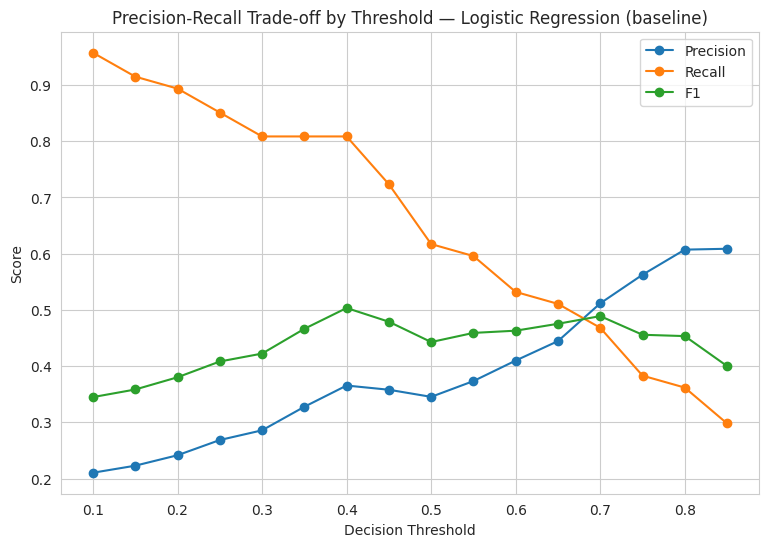

,threshold,precision,recall,f1
0,0.10,0.210280,0.957447,0.344828
1,0.15,0.222798,0.914894,0.358333
2,0.20,0.241379,0.893617,0.380090
3,0.25,0.268456,0.851064,0.408163
4,0.30,0.285714,0.808511,0.422222
5,0.35,0.327586,0.808511,0.466258
6,0.40,0.365385,0.808511,0.503311
7,0.45,0.357895,0.723404,0.478873
8,0.50,0.345238,0.617021,0.442748
9,0.55,0.373333,0.595745,0.459016


In [24]:
# Explore how shifting the decision threshold trades off precision vs recall for the attrition class
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []
for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

plt.figure(figsize=(9,6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title(f"Precision-Recall Trade-off by Threshold — {best_model_name}")
plt.legend()
plt.show()

threshold_df

---
## Summary

- Attrition is a minority class (typically ~16% of employees in this dataset), so accuracy alone is misleading — precision, recall, F1, and the confusion matrix on the attrition class tell the real story.
- Categorical HR fields (department, job role, overtime, etc.) were one-hot encoded; a few constant/ID columns were dropped as non-informative.
- Multiple classifiers were compared (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting), selecting the best by F1-score on the attrition class rather than raw accuracy.
- Cross-validation and a train-vs-test comparison confirmed whether the chosen model generalizes rather than overfits.
- The threshold analysis shows how HR could shift the model's sensitivity — trading some false alarms for catching more true attrition cases — depending on how costly a missed departure is versus an unnecessary retention conversation.